In [3]:
# Import the libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

In [2]:
!pip install yfinance

======= Complete Stock Analyser ======== 


Enter the stock symbol (Add '.NS' in case of Indian Stocks) (or Q to Quit): NVDA



-------------------------
 Company Name: NVIDIA Corporation
 Current Price: 188.63 USD
 Change : +4.69 (+2.55%)

-------------------------


[*********************100%***********************]  1 of 1 completed


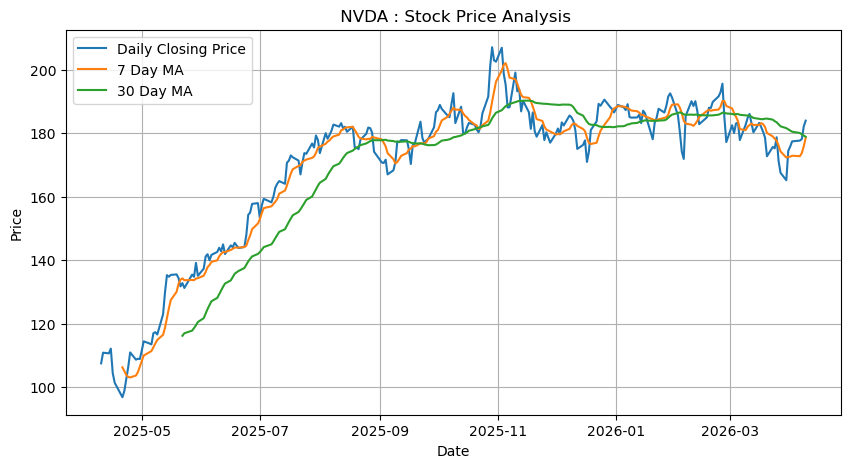

In [ ]:
print("======= Complete Stock Analyser ======== ")

while True :

    symbol = input("Enter the stock symbol (Add '.NS' in case of Indian Stocks) (or Q to Quit):").upper()

    if symbol == "Q":
        print("Thanks for using. See you again !!")
        break

  
    try:
        stock = yf.Ticker(symbol)
        info = stock.info

        name = info.get("longName","N/A")
        price = info.get("currentPrice")
        prev_price= info.get("previousClose")
        currency = info.get("currency")

        if currency is None:
            if symbol.endswith(".NS"):
                currency="₹"
            else:
                currency = "$"
        
        print("\n-------------------------")
        print(f" Company Name: {name}")
        print(f" Current Price: {price} {currency}")
        
        if price and prev_price:
            change = price - prev_price
            percent = (change/prev_price)*100
            print(f" Change : {change:+.2f} ({percent:+.2f}%)")
        
        print("\n-------------------------")


        df = yf.download(symbol, start= "2025-04-10", end = "2026-04-10", interval="1d")

        df["7_day_MA"] = df["Close"].rolling(window=7).mean()
        df["30_day_MA"] = df["Close"].rolling(window=30).mean()

        # Plot the Graph

        plt.figure(figsize=(10,5))
        plt.plot(df["Close"],label="Daily Closing Price")
        plt.plot(df["7_day_MA"],label="7 Day MA")
        plt.plot(df["30_day_MA"],label="30 Day MA")
        plt.title(f" {symbol} : Stock Price Analysis")
        plt.xlabel("Date")
        plt.ylabel("Price")
        plt.legend()
        plt.grid(True)
        plt.show()

    
    except Exception as e:
        print("Invalid Symbol or Network error\n")